# Payment Card Fraud Analytics Report Notebook

This notebook summarizes the final business analysis for the Payment Card Fraud Analytics project.

The data preparation was completed in the separate notebook `Data_preparation.ipynb`.

This report notebook uses the cleaned CSV files from the `cleaned_data` folder and creates simple summary tables and visualizations for the four project research questions.

## 1. Import Libraries and Load Cleaned Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

cleaned_data_folder = "../cleaned_data"

print(os.listdir(cleaned_data_folder))

['transactions_clean.csv', 'time_series_stats_clean.csv', 'fraud_patterns_clean.csv', 'network_edges_clean.csv', 'account_profiles_clean.csv']


In [2]:
transactions_df = pd.read_csv(os.path.join(cleaned_data_folder, "transactions_clean.csv"))
account_profiles_df = pd.read_csv(os.path.join(cleaned_data_folder, "account_profiles_clean.csv"))
fraud_patterns_df = pd.read_csv(os.path.join(cleaned_data_folder, "fraud_patterns_clean.csv"))
network_edges_df = pd.read_csv(os.path.join(cleaned_data_folder, "network_edges_clean.csv"))
time_series_stats_df = pd.read_csv(os.path.join(cleaned_data_folder, "time_series_stats_clean.csv"))

In [3]:
print("Transactions:", transactions_df.shape)
print("Account profiles:", account_profiles_df.shape)
print("Fraud patterns:", fraud_patterns_df.shape)
print("Network edges:", network_edges_df.shape)
print("Time series stats:", time_series_stats_df.shape)

Transactions: (1000000, 20)
Account profiles: (50000, 23)
Fraud patterns: (8, 12)
Network edges: (7411, 6)
Time series stats: (26280, 10)


## 2. Research Question 1

### Which fraud patterns generate the highest financial losses?

This analysis looks only at fraudulent transactions and summarizes the total fraud loss by fraud pattern.

In [4]:
fraud_transactions_df = transactions_df[transactions_df["is_fraud"] == 1].copy()

q1_fraud_loss = (
    fraud_transactions_df
    .groupby("fraud_pattern")
    .agg({
        "transaction_id": "count",
        "amount": ["sum", "mean"]
    })
)

q1_fraud_loss.columns = [
    "fraud_transactions",
    "total_fraud_loss",
    "avg_fraud_amount"
]

q1_fraud_loss = q1_fraud_loss.reset_index()

q1_fraud_loss["share_of_total_fraud_loss_pct"] = (
    q1_fraud_loss["total_fraud_loss"] / q1_fraud_loss["total_fraud_loss"].sum() * 100
)

q1_fraud_loss = q1_fraud_loss.sort_values("total_fraud_loss", ascending=False)

q1_fraud_loss

,fraud_pattern,fraud_transactions,total_fraud_loss,avg_fraud_amount,share_of_total_fraud_loss_pct
2,card_not_present,5982,4616806.56,771.783109,36.885073
0,account_takeover,3432,4129144.46,1203.130670,32.988992
3,card_present_stolen,3120,1737328.15,556.835946,13.880044
5,identity_theft,656,763253.67,1163.496448,6.097866
4,friendly_fraud,1726,608610.35,352.613181,4.862373
1,atm_fraud,1216,566971.58,466.259523,4.529709
6,money_laundering,1011,94619.32,93.589832,0.755943


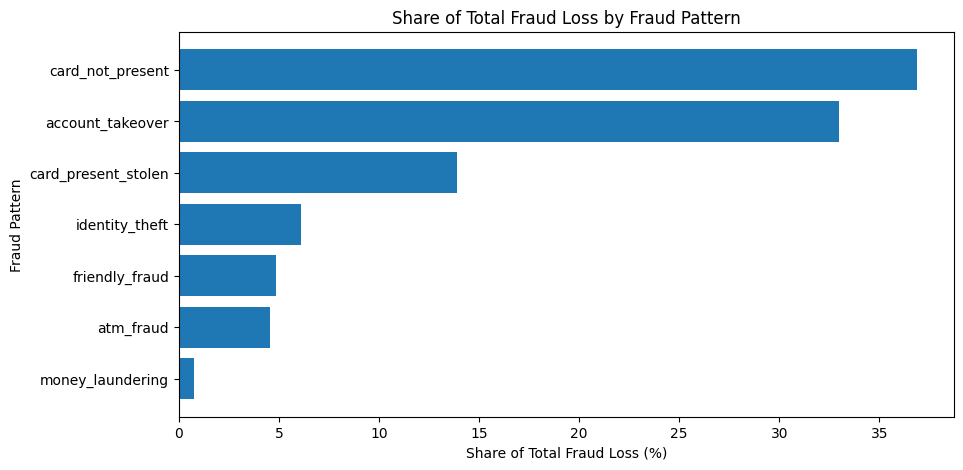

In [5]:
plt.figure(figsize=(10, 5))

plt.barh(
    q1_fraud_loss["fraud_pattern"],
    q1_fraud_loss["share_of_total_fraud_loss_pct"]
)

plt.xlabel("Share of Total Fraud Loss (%)")
plt.ylabel("Fraud Pattern")
plt.title("Share of Total Fraud Loss by Fraud Pattern")
plt.gca().invert_yaxis()
plt.show()

### Key finding

Card Not Present and Account Takeover generated the highest financial losses. Together, these two fraud patterns represent most of the fraud loss in the dataset.

## 3. Research Question 2

### Which customer account characteristics are associated with higher fraud risk?

This section compares fraud rates across account characteristics.

In [6]:
q2_2fa = (
    account_profiles_df
    .groupby("has_2fa")
    .agg({
        "account_id": "count",
        "is_fraudster": "sum"
    })
    .reset_index()
)

q2_2fa.columns = ["has_2fa", "total_accounts", "fraud_accounts"]

q2_2fa["fraud_rate_pct"] = (
    q2_2fa["fraud_accounts"] / q2_2fa["total_accounts"] * 100
)

q2_2fa

,has_2fa,total_accounts,fraud_accounts,fraud_rate_pct
0,0,17567,5349.0,30.449138
1,1,32433,7987.0,24.626152


In [7]:
q2_age = account_profiles_df.copy()

q2_age["account_age_group"] = pd.cut(
    q2_age["account_age_days"],
    bins=[0, 30, 180, 365, q2_age["account_age_days"].max()],
    labels=["Less than 30 days", "30 - 180 days", "181 - 365 days", "More than 365 days"],
    include_lowest=True
)

q2_account_age = (
    q2_age
    .groupby("account_age_group")
    .agg({
        "account_id": "count",
        "is_fraudster": "sum"
    })
    .reset_index()
)

q2_account_age.columns = ["account_age_group", "total_accounts", "fraud_accounts"]

q2_account_age["fraud_rate_pct"] = (
    q2_account_age["fraud_accounts"] / q2_account_age["total_accounts"] * 100
)

q2_account_age

/var/folders/78/t5h6877j2g55pnl84stmyl1h0000gn/T/ipykernel_64921/3342526740.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q2_age


,account_age_group,total_accounts,fraud_accounts,fraud_rate_pct
0,Less than 30 days,13,5.0,38.461538
1,30 - 180 days,2121,663.0,31.258840
2,181 - 365 days,2511,696.0,27.718041
3,More than 365 days,45355,11972.0,26.396208


In [8]:
q2_account_type = (
    account_profiles_df
    .groupby("account_type")
    .agg({
        "account_id": "count",
        "is_fraudster": "sum"
    })
    .reset_index()
)

q2_account_type.columns = ["account_type", "total_accounts", "fraud_accounts"]

q2_account_type["fraud_rate_pct"] = (
    q2_account_type["fraud_accounts"] / q2_account_type["total_accounts"] * 100
)

q2_account_type = q2_account_type.sort_values("fraud_rate_pct", ascending=False)

q2_account_type

,account_type,total_accounts,fraud_accounts,fraud_rate_pct
0,business,9988,2731.0,27.342811
1,personal,35061,9327.0,26.602208
2,premium,4951,1278.0,25.812967


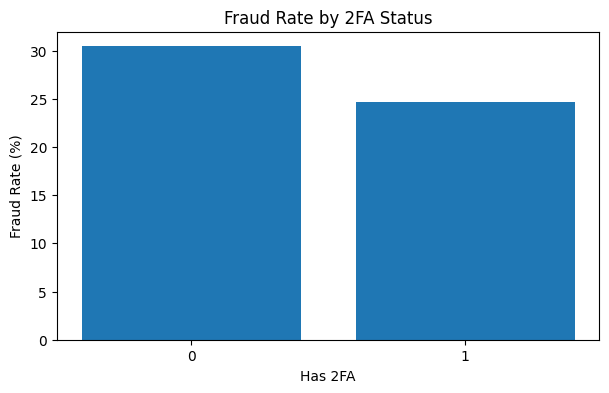

In [9]:
plt.figure(figsize=(7, 4))

plt.bar(
    q2_2fa["has_2fa"].astype(str),
    q2_2fa["fraud_rate_pct"]
)

plt.xlabel("Has 2FA")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by 2FA Status")
plt.show()

### Key finding

Accounts without 2FA and newer accounts showed higher fraud rates. Account type showed smaller differences across customer groups.

## 4. Research Question 3

### Which transaction behaviours are most strongly associated with fraudulent activity?

This section compares fraud rates across transaction behaviours.

In [10]:
q3_velocity = transactions_df.copy()

def velocity_group(value):
    if value == 0:
        return "No Previous Transactions"
    elif value <= 2:
        return "Low Velocity (1-2)"
    elif value <= 5:
        return "Moderate Velocity (3-5)"
    else:
        return "High Velocity (6+)"

q3_velocity["velocity_group"] = q3_velocity["velocity_1h"].apply(velocity_group)

q3_velocity_summary = (
    q3_velocity
    .groupby("velocity_group")
    .agg({
        "transaction_id": "count",
        "is_fraud": "sum"
    })
    .reset_index()
)

q3_velocity_summary.columns = ["velocity_group", "total_transactions", "fraud_transactions"]

q3_velocity_summary["fraud_rate_pct"] = (
    q3_velocity_summary["fraud_transactions"] / q3_velocity_summary["total_transactions"] * 100
)

q3_velocity_summary = q3_velocity_summary.sort_values("fraud_rate_pct", ascending=False)

q3_velocity_summary

,velocity_group,total_transactions,fraud_transactions,fraud_rate_pct
0,High Velocity (6+),4227,3623,85.710906
2,Moderate Velocity (3-5),87546,9314,10.638978
1,Low Velocity (1-2),546017,3881,0.710784
3,No Previous Transactions,362210,325,0.089727


In [11]:
q3_foreign = (
    transactions_df
    .groupby("is_foreign_txn")
    .agg({
        "transaction_id": "count",
        "is_fraud": "sum"
    })
    .reset_index()
)

q3_foreign.columns = ["is_foreign_txn", "total_transactions", "fraud_transactions"]

q3_foreign["fraud_rate_pct"] = (
    q3_foreign["fraud_transactions"] / q3_foreign["total_transactions"] * 100
)

q3_foreign

,is_foreign_txn,total_transactions,fraud_transactions,fraud_rate_pct
0,0,705583,7145,1.012638
1,1,294417,9998,3.395864


In [12]:
q3_merchant = (
    transactions_df
    .groupby("merchant_category")
    .agg({
        "transaction_id": "count",
        "is_fraud": "sum"
    })
    .reset_index()
)

q3_merchant.columns = ["merchant_category", "total_transactions", "fraud_transactions"]

q3_merchant["fraud_rate_pct"] = (
    q3_merchant["fraud_transactions"] / q3_merchant["total_transactions"] * 100
)

q3_merchant = q3_merchant.sort_values("fraud_rate_pct", ascending=False)

q3_merchant.head(10)

,merchant_category,total_transactions,fraud_transactions,fraud_rate_pct
2,crypto,19976,1067,5.341410
8,money_transfer,30079,1242,4.129127
4,gambling,9920,354,3.568548
12,travel,49367,1288,2.609030
3,electronics,60229,1372,2.277972
7,hotel,49490,734,1.483128
11,restaurant,120406,1771,1.470857
0,atm,79595,1163,1.461147
5,gas_station,80030,1157,1.445708
1,clothing,70072,1000,1.427104


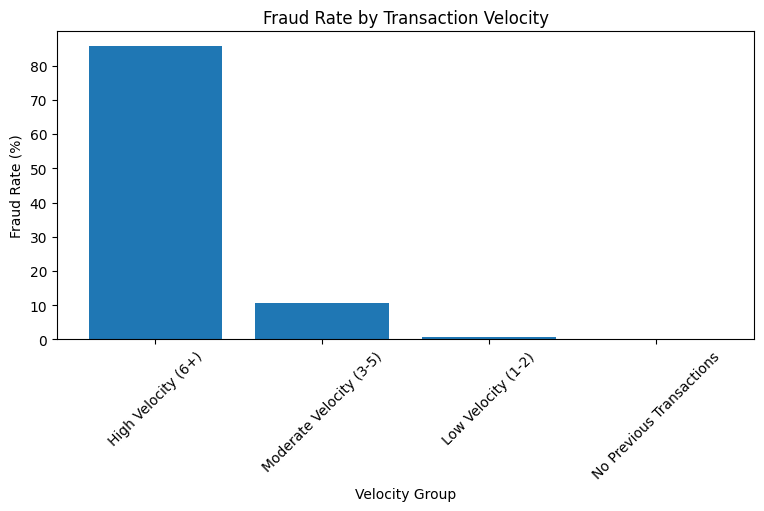

In [13]:
plt.figure(figsize=(9, 4))

plt.bar(
    q3_velocity_summary["velocity_group"],
    q3_velocity_summary["fraud_rate_pct"]
)

plt.xlabel("Velocity Group")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Velocity")
plt.xticks(rotation=45)
plt.show()

### Key finding

High transaction velocity showed the strongest fraud association in the dataset. Foreign transactions and certain merchant categories also showed higher fraud rates.

## 5. Research Question 4

### Can network analysis identify coordinated fraud rings and high risk account clusters?

This section summarizes fraud rings using the network edges dataset.

In [14]:
fraud_rings_df = network_edges_df[
    network_edges_df["ring_id"].notna() & 
    (network_edges_df["ring_id"].astype(str).str.strip() != "")
].copy()

q4_summary = pd.DataFrame({
    "metric": [
        "identified_fraud_rings",
        "fraud_ring_connections",
        "total_shared_connections",
        "avg_shared_connections"
    ],
    "value": [
        fraud_rings_df["ring_id"].nunique(),
        len(fraud_rings_df),
        fraud_rings_df["connection_count"].sum(),
        fraud_rings_df["connection_count"].mean()
    ]
})

q4_summary

,metric,value
0,identified_fraud_rings,200.000000
1,fraud_ring_connections,4411.000000
2,total_shared_connections,35086.000000
3,avg_shared_connections,7.954205


In [15]:
q4_top_rings = (
    fraud_rings_df
    .groupby("ring_id")
    .agg({
        "account_a": "count",
        "connection_count": ["sum", "mean", "max"]
    })
)

q4_top_rings.columns = [
    "network_connections",
    "total_shared_connections",
    "avg_shared_connections",
    "max_shared_connections"
]

q4_top_rings = q4_top_rings.reset_index()

q4_top_rings = q4_top_rings.sort_values(
    "total_shared_connections",
    ascending=False
).head(10)

q4_top_rings

,ring_id,network_connections,total_shared_connections,avg_shared_connections,max_shared_connections
147,RING0148,55,509,9.254545,14
100,RING0101,55,466,8.472727,14
199,RING0200,55,455,8.272727,14
137,RING0138,55,441,8.018182,14
178,RING0179,55,436,7.927273,14
55,RING0056,55,435,7.909091,14
56,RING0057,55,430,7.818182,14
105,RING0106,55,429,7.800000,14
164,RING0165,55,426,7.745455,14
71,RING0072,55,424,7.709091,14


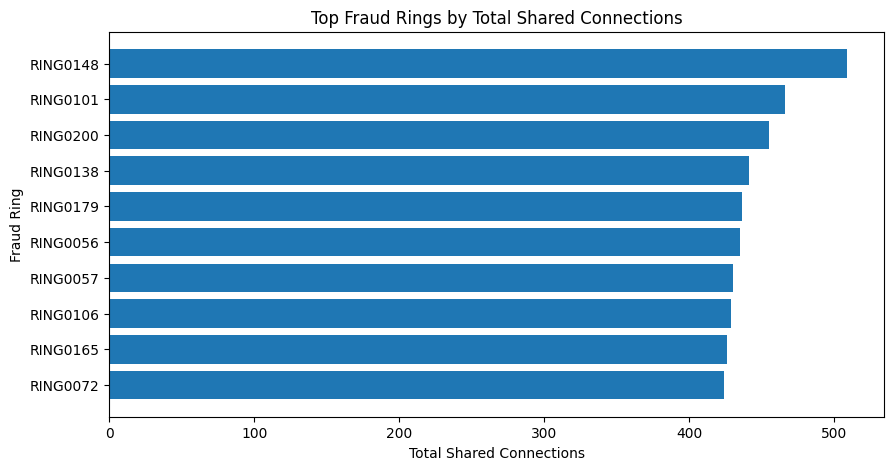

In [16]:
plt.figure(figsize=(10, 5))

plt.barh(
    q4_top_rings["ring_id"],
    q4_top_rings["total_shared_connections"]
)

plt.xlabel("Total Shared Connections")
plt.ylabel("Fraud Ring")
plt.title("Top Fraud Rings by Total Shared Connections")
plt.gca().invert_yaxis()
plt.show()

### Key finding

Network analysis identified fraud rings and high activity clusters. The top fraud ring was ranked by total shared connections.

## 6. Overall Conclusion

The analysis shows that fraud risk is not evenly distributed across the dataset.

Main conclusions:

1. Fraud losses are concentrated in a small number of fraud patterns.
2. Accounts without 2FA and newer accounts show higher fraud rates.
3. Transaction velocity is the strongest behavioural fraud signal identified.
4. Network data can help identify high activity fraud rings and suspicious account clusters.

These findings support a layered fraud monitoring approach combining fraud pattern prioritization, account security, transaction behaviour monitoring, and network analysis.